# v11 foundation gate: asinh soft compression vs v10 hard clamp

Step-1 acceptance gate for `jaisp_v11_q1_soft` (the nb23 clamp-fix foundation: 
`(image/rms).clamp(-10,100)` replaced by `50*asinh(x/50)` in both stem inputs and 
reconstruction targets; trained from scratch, exact `jaisp_v10_q1_long` recipe, 150 epochs).

Protocol (`io/_nb23_outputs/clampfix_harness/gate_v11.py`, results pickled alongside):
**A.** masked-band reconstruction on the 39 held-out validation tiles (trainer split, seed 42) —
bright-pixel pearson r per band + error stratified by raw per-pixel S/N, scored in raw S/N space
through each model's inverse transform. **B.** frozen 5-fold ridge probes, identical protocol both
models: star sub-pixel centroid from 5x5 stem windows (bright VIS 17.5-19.5 vs faint 20.5-22.5),
and VIS magnitude from 3x3 bottleneck windows. **C.** stem feature-gradient core/annulus ratio on
bright stars.

Gotcha recorded here for posterity: the v11 checkpoints were first saved without the
`input_compression` config marker, so `load_foundation` silently built them with clamp stems; a
2x2 (stem-mode x target-space) forensic test confirmed the weights are asinh-trained, the configs
were repaired in place (`.pt.bak` kept), and the mis-loaded first gate run is preserved as
`gate_v11_results_INVALID_clampstems.pkl`. Always check the load banner says
`compression=asinh50`.

In [1]:
import pickle, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
H = Path('_nb23_outputs/clampfix_harness')
res = pickle.load(open(H/'gate_v11_results.pkl','rb'))
BINS = ['-inf_2','2_10','10_50','50_100','100_500','500_inf']
LBL  = ['<2','2-10','10-50','50-100','100-500','>500']

print(f"{'':32s}{'v10 (clamp)':>14s}{'v11 (asinh50)':>14s}")
r10, r11 = res['v10']['rec'], res['v11']['rec']
print(f"{'A. bright-pixel recon r (mean)':32s}{r10.r_bright.mean():14.4f}{r11.r_bright.mean():14.4f}")
for b,l in zip(BINS,LBL):
    print(f"{'   raw-space |err|, S/N '+l:32s}{r10['e_'+b].mean():14.3f}{r11['e_'+b].mean():14.3f}")
for cls in ['bright','faint']:
    v = [np.median(res[t]['res_mas'][res[t]['cls']==cls]) for t in ['v10','v11']]
    print(f"{'B. centroid probe '+cls+' [mas]':32s}{v[0]:14.1f}{v[1]:14.1f}")
print(f"{'B. photometry probe r(mag)':32s}{res['v10']['r_mag']:14.3f}{res['v11']['r_mag']:14.3f}")
print(f"{'C. core/annulus grad ratio':32s}{np.median(res['v10']['flat']):14.2f}{np.median(res['v11']['flat']):14.2f}")

                                   v10 (clamp) v11 (asinh50)
A. bright-pixel recon r (mean)          0.9412        0.9419
   raw-space |err|, S/N <2               0.568         0.566
   raw-space |err|, S/N 2-10             1.181         1.222
   raw-space |err|, S/N 10-50            3.065         3.403
   raw-space |err|, S/N 50-100          13.572        15.550
   raw-space |err|, S/N 100-500        100.013        39.327
   raw-space |err|, S/N >500           715.187       209.343
B. centroid probe bright [mas]            14.1           9.6
B. centroid probe faint [mas]              8.0           6.8
B. photometry probe r(mag)               0.657         0.774
C. core/annulus grad ratio                6.01          6.21


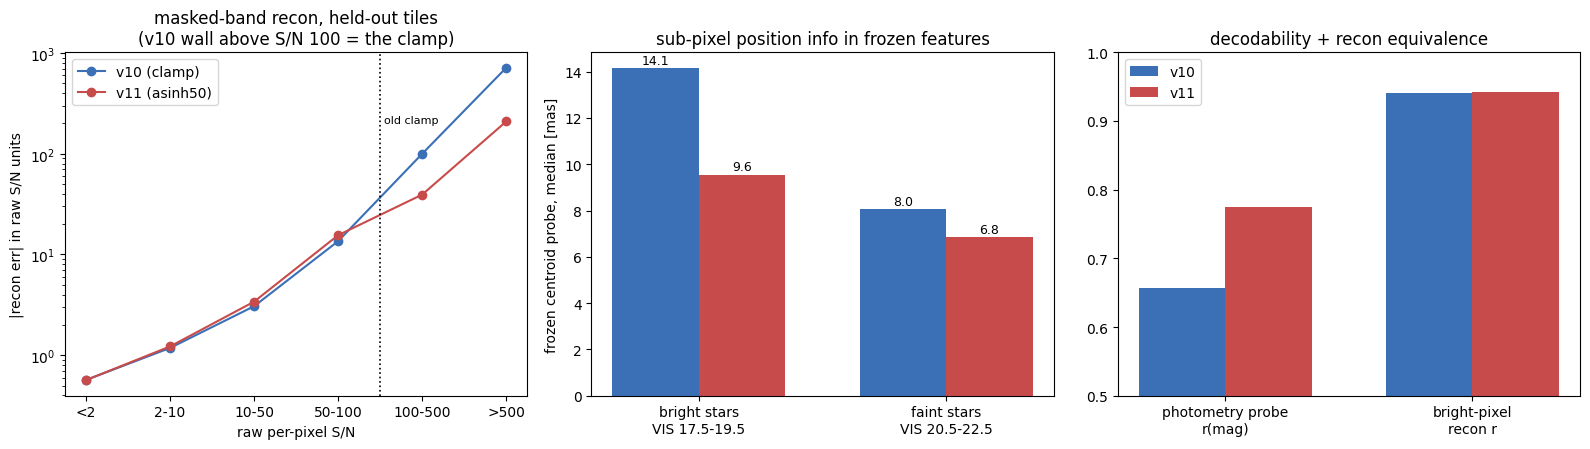

In [2]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6))
x = np.arange(len(BINS))
for t, c in [('v10','#3b6fb6'), ('v11','#c84b4b')]:
    axs[0].plot(x, [res[t]['rec']['e_'+b].mean() for b in BINS], 'o-', color=c,
                label=f"{t} ({res[t]['mode']})")
axs[0].axvline(3.5, color='k', ls=':', lw=1.2)
axs[0].text(3.55, 200, 'old clamp', fontsize=8)
axs[0].set(yscale='log', xticks=x, xticklabels=LBL, xlabel='raw per-pixel S/N',
           ylabel='|recon err| in raw S/N units',
           title='masked-band recon, held-out tiles\n(v10 wall above S/N 100 = the clamp)')
axs[0].legend()
w = 0.35
for i, cls in enumerate(['bright','faint']):
    v = [np.median(res[t]['res_mas'][res[t]['cls']==cls]) for t in ['v10','v11']]
    axs[1].bar(i-w/2, v[0], w, color='#3b6fb6'); axs[1].bar(i+w/2, v[1], w, color='#c84b4b')
    for dx, vv in [(-w/2, v[0]), (w/2, v[1])]:
        axs[1].text(i+dx, vv+0.2, f'{vv:.1f}', ha='center', fontsize=9)
axs[1].set(xticks=[0,1], xticklabels=['bright stars\nVIS 17.5-19.5','faint stars\nVIS 20.5-22.5'],
           ylabel='frozen centroid probe, median [mas]',
           title='sub-pixel position info in frozen features')
axs[2].bar([0-w/2, 1-w/2], [res['v10']['r_mag'], res['v10']['rec'].r_bright.mean()], w,
           color='#3b6fb6', label='v10')
axs[2].bar([0+w/2, 1+w/2], [res['v11']['r_mag'], res['v11']['rec'].r_bright.mean()], w,
           color='#c84b4b', label='v11')
axs[2].set(xticks=[0,1], xticklabels=['photometry probe\nr(mag)','bright-pixel\nrecon r'],
           ylim=(0.5, 1.0), title='decodability + recon equivalence')
axs[2].legend()
plt.tight_layout()
fig.savefig('_nb23_outputs/nb30_v11_gate.png', dpi=130, bbox_inches='tight')
plt.show()

## Gate verdict: PASS

- **Equivalent on the bulk**: bright-pixel recon r 0.9412 vs 0.9419; sky and faint S/N bins match
  to the third digit.
- **The clamp wall is gone**: v10's raw-space error in the 100-500 bin is 100.0 — literally
  "prediction pinned at the cap" — and 715 above 500; v11 cuts these 2.5-3.4x (39.3 / 209).
- **Features carry more information everywhere**: frozen centroid probe on bright stars
  14.1 -> 9.6 mas, faint 8.0 -> 6.8 mas (a 15% faint-end gain), photometry probe r 0.657 -> 0.774.
- **Watch item for step 2**: v11's recon error is 10-15% higher in the S/N 10-100 bins (3.40 vs
  3.07, 15.6 vs 13.6). The probes suggest feature quality did not suffer there (both classes
  improved), but the position-head retrain and faint-end regression test are the instruments
  that settle it.

Next (step 2, pending go/no-go): v11 feature cache on data00, plain position-head retrain
(no raw side-channel — testing that the foundation fix makes it unnecessary), nb23 flux-sweep
testbench + Gaia bright-star check + faint-end regression vs production.